# Industrial hybrid bidding strategy diagrams

Three matched, 16:9 schematic figures for presentation use. All three routes are supported by the current industrial-hybrid strategy. Profiles and market outcomes are illustrative and are not ASSUME simulation results.

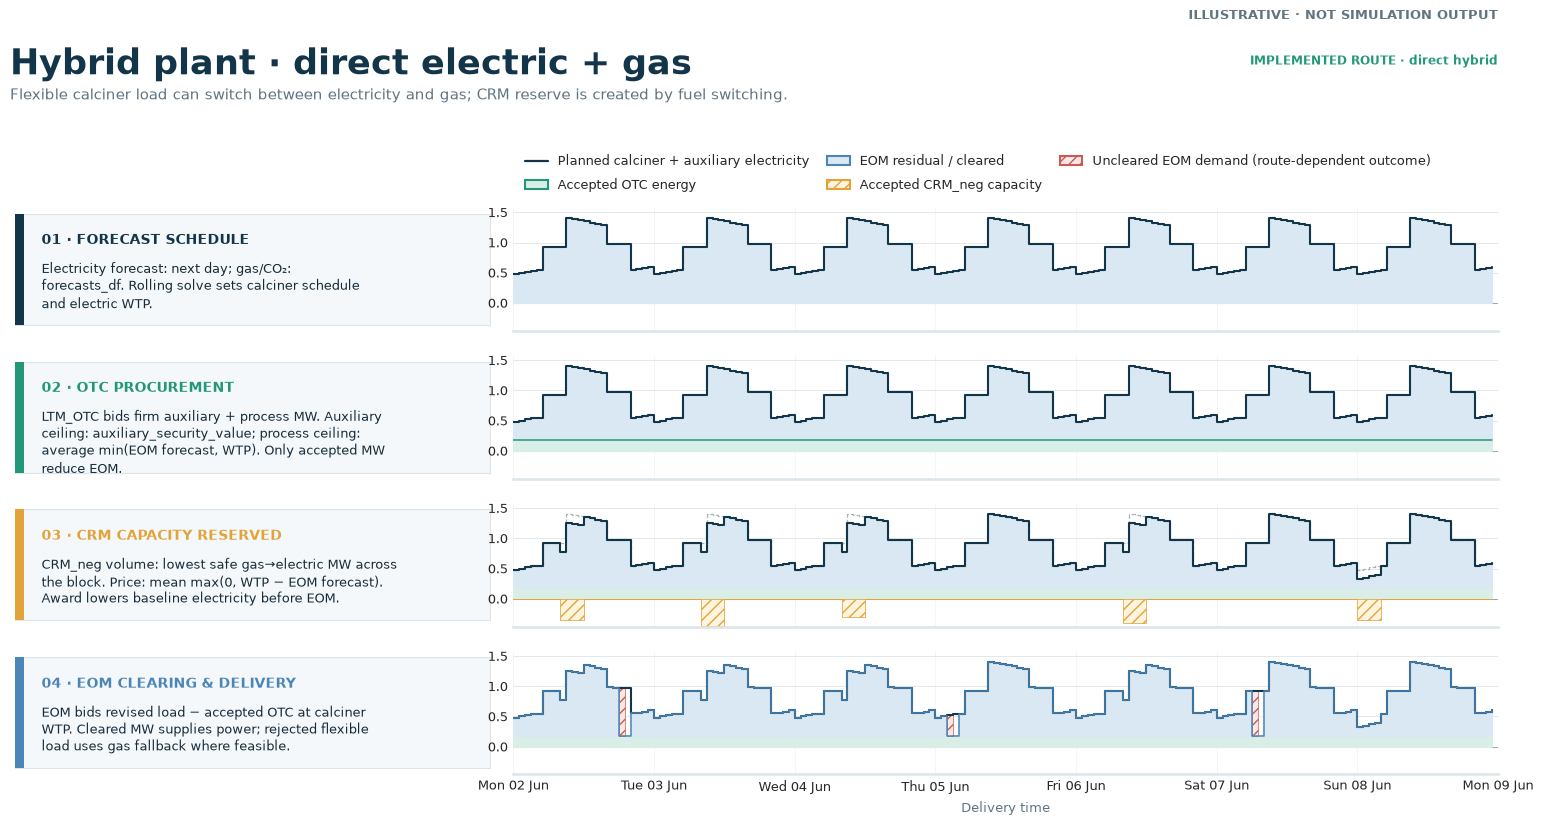

Saved /root/assume/examples/notebooks/industrial_hybrid_strategy_direct.png
Route note: Gas substitutes for rejected flexible calciner electricity; any remaining production gap is unserved.


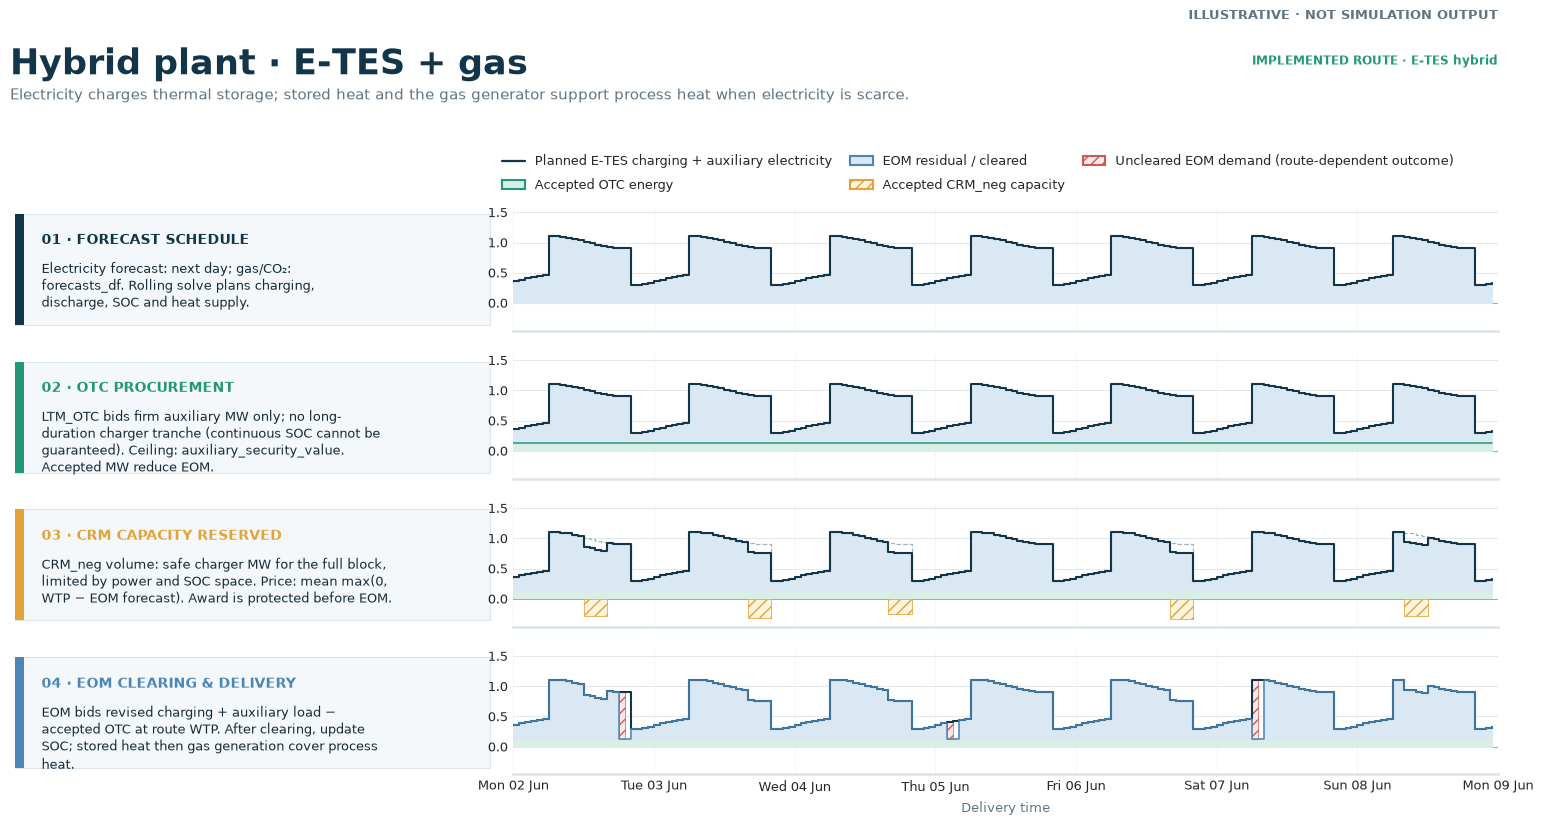

Saved /root/assume/examples/notebooks/industrial_hybrid_strategy_etes.png
Route note: EOM shortfall first affects charging; available stored heat is used, then gas generation, then clinker shortfall.


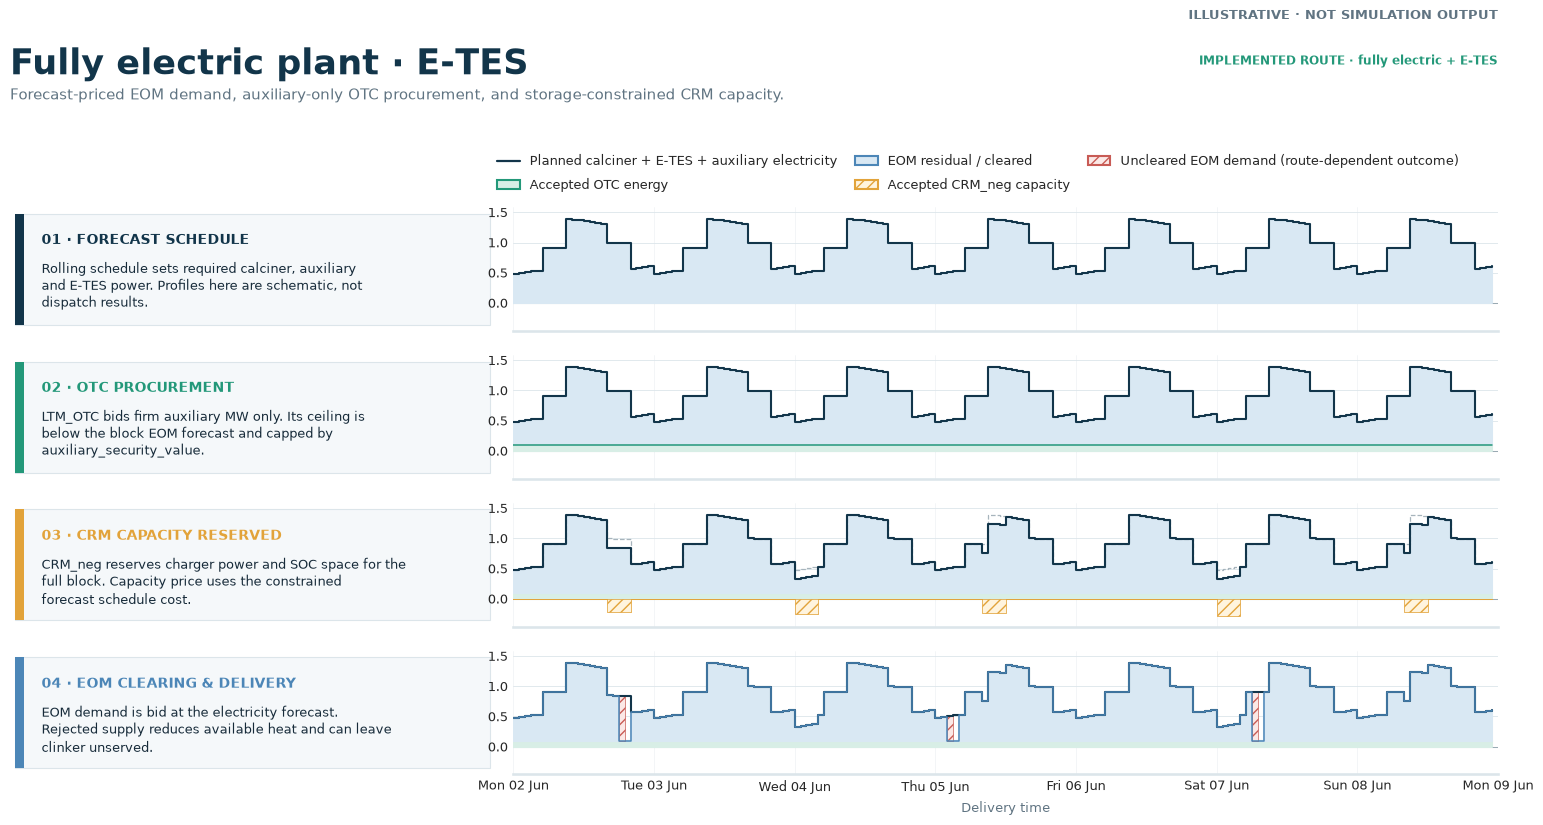

Saved /root/assume/examples/notebooks/industrial_hybrid_strategy_full_electric_etes.png
Route note: No gas fallback; an electricity shortfall can result in unserved clinker.


In [12]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import textwrap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# All profiles below are illustrative. Replace them with ASSUME output when
# preparing a results slide; they are not simulation data.
time = pd.date_range("2025-06-02", periods=168, freq="h")
hour = np.arange(len(time)) % 24
daily = np.select([hour < 5, hour < 9, hour < 16, hour < 20],
                  [.48, .85, 1.35, 1.05], default=.62)
direct_load = np.clip(daily + .08 * np.sin(hour * np.pi / 12), .4, None)
etes_load = np.clip(.36 + .65 * (hour % 24 >= 6) * (hour % 24 <= 19)
                    + .10 * np.sin(hour * np.pi / 12), .30, None)
all_electric_load = np.clip(daily + .06 * np.sin(hour * np.pi / 12), .45, None)

palette = {
    "navy": "#12354A", "ink": "#172B3A", "muted": "#607482",
    "grid": "#DCE5EA", "blue": "#4C86B7", "bluefill": "#D9E8F3",
    "green": "#239879", "greenfill": "#D8EEE6", "amber": "#E2A33A",
    "red": "#C85B55", "paper": "#F5F8FA",
}
sns.set_theme(
    style="whitegrid", context="talk", font_scale=.8,
    rc={"font.family": "DejaVu Sans", "axes.titleweight": "bold",
        "figure.facecolor": "white", "savefig.facecolor": "white",
        "pdf.fonttype": 42, "ps.fonttype": 42},
)

# Identical market sequence and four profile stages make route differences
# easy to compare. Bid/price explanations are route-specific.
scenarios = [
    {
        "file": "industrial_hybrid_strategy_direct.png",
        "title": "Hybrid plant · direct electric + gas",
        "subtitle": "Flexible calciner load can switch between electricity and gas; CRM reserve is created by fuel switching.",
        "load": direct_load, "otc_fraction": .18, "reserve_level": .34,
        "reserve_hours": [(8,.35),(32,.45),(56,.30),(104,.40),(144,.35)],
        "status": "IMPLEMENTED ROUTE · direct hybrid",
        "steps": [
            "Electricity forecast: next day; gas/CO₂: forecasts_df. Rolling solve sets calciner schedule and electric WTP.",
            "LTM_OTC bids firm auxiliary + process MW. Auxiliary ceiling: auxiliary_security_value; process ceiling: average min(EOM forecast, WTP). Only accepted MW reduce EOM.",
            "CRM_neg volume: lowest safe gas→electric MW across the block. Price: mean max(0, WTP − EOM forecast). Award lowers baseline electricity before EOM.",
            "EOM bids revised load − accepted OTC at calciner WTP. Cleared MW supplies power; rejected flexible load uses gas fallback where feasible.",
        ],
        "otc_note": "OTC price ceiling: auxiliary_security_value (auxiliary); mean min(EOM forecast, WTP) (process).",
        "crm_note": "CRM price = reservation opportunity cost; block volume = lowest safe MW across all block hours.",
        "delivery_note": "Gas substitutes for rejected flexible calciner electricity; any remaining production gap is unserved.",
        "load_name": "Planned calciner + auxiliary electricity",
    },
    {
        "file": "industrial_hybrid_strategy_etes.png",
        "title": "Hybrid plant · E‑TES + gas",
        "subtitle": "Electricity charges thermal storage; stored heat and the gas generator support process heat when electricity is scarce.",
        "load": etes_load, "otc_fraction": .13, "reserve_level": .30,
        "reserve_hours": [(12,.28),(40,.32),(64,.26),(112,.34),(152,.28)],
        "status": "IMPLEMENTED ROUTE · E‑TES hybrid",
        "steps": [
            "Electricity forecast: next day; gas/CO₂: forecasts_df. Rolling solve plans charging, discharge, SOC and heat supply.",
            "LTM_OTC bids firm auxiliary MW only; no long-duration charger tranche (continuous SOC cannot be guaranteed). Ceiling: auxiliary_security_value. Accepted MW reduce EOM.",
            "CRM_neg volume: safe charger MW for the full block, limited by power and SOC space. Price: mean max(0, WTP − EOM forecast). Award is protected before EOM.",
            "EOM bids revised charging + auxiliary load − accepted OTC at route WTP. After clearing, update SOC; stored heat then gas generation cover process heat.",
        ],
        "otc_note": "Auxiliary tranche ceiling = configured auxiliary_security_value; accepted contract is pay-as-bid physical energy.",
        "crm_note": "CRM price = reservation opportunity cost; volume is safe charger MW over the full block and SOC headroom.",
        "delivery_note": "EOM shortfall first affects charging; available stored heat is used, then gas generation, then clinker shortfall.",
        "load_name": "Planned E‑TES charging + auxiliary electricity",
    },
    {
        "file": "industrial_hybrid_strategy_full_electric_etes.png",
        "title": "Fully electric plant · E‑TES",
        "subtitle": "Forecast-priced EOM demand, auxiliary-only OTC procurement, and storage-constrained CRM capacity.",
        "load": all_electric_load, "otc_fraction": .10, "reserve_level": .28,
        "reserve_hours": [(16,.22),(48,.26),(80,.24),(120,.28),(152,.22)],
        "status": "IMPLEMENTED ROUTE · fully electric + E‑TES",
        "steps": [
            "Rolling schedule sets required calciner, auxiliary and E‑TES power. Profiles here are schematic, not dispatch results.",
            "LTM_OTC bids firm auxiliary MW only. Its ceiling is below the block EOM forecast and capped by auxiliary_security_value.",
            "CRM_neg reserves charger power and SOC space for the full block. Capacity price uses the constrained forecast schedule cost.",
            "EOM demand is bid at the electricity forecast. Rejected supply reduces available heat and can leave clinker unserved.",
        ],
        "otc_note": "Auxiliary OTC demand only; accepted contracts reduce EOM residual demand.",
        "crm_note": "CRM capacity is a separate reserve commitment, not delivered energy.",
        "delivery_note": "No gas fallback; an electricity shortfall can result in unserved clinker.",
        "load_name": "Planned calciner + E‑TES + auxiliary electricity",
    },
]

def draw_scenario(scenario):
    required = scenario["load"]
    otc = np.full(len(time), scenario["otc_fraction"])
    reserve = np.zeros(len(time))
    for start, volume in scenario["reserve_hours"]:
        reserve[start:start + 4] = volume

    # Illustrative reservation-aware re-solve: accepted reserve changes the
    # electric schedule. It is not a dispatch/activation energy profile.
    revised = np.maximum(.28, required - np.where(reserve > 0, .15, 0))
    eom_after_otc = np.maximum(0, required - otc)
    eom_after_crm = np.maximum(0, revised - otc)

    # Illustrative EOM results: a few intervals fail to clear.
    eom_cleared = eom_after_crm.copy()
    eom_cleared[[18, 19, 74, 75, 126, 127]] = 0
    procured = otc + eom_cleared
    gap = np.maximum(0, revised - procured)

    fig = plt.figure(figsize=(16, 9), facecolor="white")
    gs = fig.add_gridspec(
        4, 2, width_ratios=[.33, .67], left=.045, right=.975,
        top=.745, bottom=.115, hspace=.20, wspace=.025,
    )

    fig.text(.045, .923, scenario["title"], fontsize=25, weight="bold",
             color=palette["navy"], va="top")
    fig.text(.045, .878, scenario["subtitle"], fontsize=11,
             color=palette["muted"], va="top")
    fig.text(.975, .965, "ILLUSTRATIVE · NOT SIMULATION OUTPUT",
             fontsize=9, weight="bold", color=palette["muted"], ha="right", va="top")
    fig.text(.975, .915, scenario["status"], fontsize=8.5,
             weight="bold", color=palette["red"] if "CONCEPT" in scenario["status"] else palette["green"],
             ha="right", va="top")

    stage_heads = ["01 · FORECAST SCHEDULE", "02 · OTC PROCUREMENT",
                   "03 · CRM CAPACITY RESERVED", "04 · EOM CLEARING & DELIVERY"]
    axes = []
    for i, (head, note) in enumerate(zip(stage_heads, scenario["steps"])):
        label_ax = fig.add_subplot(gs[i, 0])
        label_ax.set_axis_off()
        accent = [palette["navy"], palette["green"], palette["amber"], palette["blue"]][i]
        label_ax.add_patch(plt.Rectangle(
            (.01, .05), .98, .90, transform=label_ax.transAxes,
            fc=palette["paper"], ec=palette["grid"], lw=.8,
        ))
        label_ax.add_patch(plt.Rectangle(
            (.01, .05), .018, .90, transform=label_ax.transAxes,
            fc=accent, ec=accent, lw=0,
        ))
        label_ax.text(.065, .79, head, transform=label_ax.transAxes,
                      fontsize=10, weight="bold", color=accent, va="top")
        label_ax.text(.065, .57, textwrap.fill(note, width=52), transform=label_ax.transAxes,
                      fontsize=9, color=palette["ink"], va="top", linespacing=1.35)

        ax = fig.add_subplot(gs[i, 1], sharex=axes[0] if axes else None)
        axes.append(ax)
        ax.axhline(0, color="#9AAAB3", lw=.75, zorder=1)
        ax.grid(axis="y", color=palette["grid"], lw=.6)
        ax.grid(axis="x", color="#EEF2F4", lw=.5)
        ax.set_ylim(-.46, 1.58)
        ax.set_xlim(time[0], time[-1] + pd.Timedelta(hours=1))
        ax.set_yticks([0, .5, 1., 1.5])
        ax.tick_params(length=0, pad=4, labelsize=9)
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.spines["bottom"].set_color(palette["grid"])
        if i < 3:
            ax.tick_params(labelbottom=False)
        else:
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
            ax.set_xlabel("Delivery time", fontsize=9, color=palette["muted"], labelpad=5)

    # Step 1: entire planned load is the starting EOM exposure.
    axes[0].fill_between(time, 0, required, step="post", color=palette["bluefill"])
    axes[0].step(time, required, where="post", color=palette["navy"], lw=1.5)

    # Step 2: accepted OTC physical energy slices off residual EOM demand.
    axes[1].fill_between(time, 0, otc, step="post", color=palette["greenfill"])
    axes[1].fill_between(time, otc, required, step="post", color=palette["bluefill"])
    axes[1].step(time, required, where="post", color=palette["navy"], lw=1.5)
    axes[1].step(time, otc, where="post", color=palette["green"], lw=1.1)

    # Step 3: CRM capacity is a separate commitment (hatched, below zero).
    axes[2].fill_between(time, 0, otc, step="post", color=palette["greenfill"])
    axes[2].fill_between(time, otc, revised, step="post", color=palette["bluefill"])
    axes[2].step(time, required, where="post", color="#A7B4BC", lw=.9, ls="--")
    axes[2].step(time, revised, where="post", color=palette["navy"], lw=1.5)
    if reserve.any():
        axes[2].fill_between(time, -reserve, 0, step="post", facecolor="#FFF4DE",
                             edgecolor=palette["amber"], hatch="///", lw=.55)

    # Step 4: cleared OTC + EOM procurement; red hatch is uncleared EOM demand.
    axes[3].fill_between(time, 0, otc, step="post", color=palette["greenfill"])
    axes[3].fill_between(time, otc, procured, step="post", color=palette["bluefill"])
    if gap.any():
        axes[3].fill_between(time, procured, revised, where=gap > 0, step="post",
                             facecolor="#FBE8E6", edgecolor=palette["red"],
                             hatch="///", lw=.5)
    axes[3].step(time, revised, where="post", color=palette["navy"], lw=1.5)
    axes[3].step(time, procured, where="post", color=palette["blue"], lw=1.1)

    legend = [
        Line2D([0], [0], color=palette["navy"], lw=1.6, label=scenario["load_name"]),
        Patch(facecolor=palette["greenfill"], edgecolor=palette["green"], label="Accepted OTC energy"),
        Patch(facecolor=palette["bluefill"], edgecolor=palette["blue"], label="EOM residual / cleared"),
        Patch(facecolor="#FFF4DE", edgecolor=palette["amber"], hatch="///", label="Accepted CRM_neg capacity"),
        Patch(facecolor="#FBE8E6", edgecolor=palette["red"], hatch="///", label="Uncleared EOM demand (route-dependent outcome)"),
    ]
    fig.legend(handles=legend, ncol=3, loc="upper center", bbox_to_anchor=(.65, .817),
               frameon=False, fontsize=9, handlelength=1.8, columnspacing=1.4,
               labelspacing=.8)

    output = Path(scenario["file"])
    for folder in (Path.cwd(), *Path.cwd().parents):
        if (folder / "assume").is_dir() and (folder / "examples/notebooks").is_dir():
            output = folder / "examples/notebooks" / scenario["file"]
            break
    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved {output.resolve()}")
    print("Route note:", scenario["delivery_note"])

for scenario in scenarios:
    draw_scenario(scenario)
